# TSS Activity and Rotation Catalog diagnostics and debugging

In [1]:
import pandas as pd
import glob
import numpy as np
import matplotlib.pyplot as plt
import pickle

In [2]:
merged_HPIC, s_index_columns, rhk_columns, vsini_columns, rotation_period_columns, activity_cycle_columns, phot_jitter_columns = pickle.load(open('HPIC+TSS3_all_columns.pkl','rb'))

## Routines

In [3]:
def make_panels(df, index_columns, select_col, lim=None):
    
    # Check if index_columns is a string and convert to list
    if isinstance(index_columns, str):
        index_columns = [index_columns]
        
    # Initialize a new figure
    n_cols = 3
    n_rows = int(np.ceil(len(index_columns) / n_cols))  # Calculate rows needed
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(10, 3.1 * n_rows))
    axs = axs.flatten()  # Flatten the 2D array of axes for easy indexing

    # Iterate over columns to create subplots
    for i, col in enumerate(index_columns):
        subset = merged_HPIC[select_col] == merged_HPIC[col]
        if len(subset)>20:
            axs[i].scatter(merged_HPIC[select_col][subset], merged_HPIC[col][subset], c='gray', marker='.', alpha=0.6)
            axs[i].scatter(merged_HPIC[select_col][~subset], merged_HPIC[col][~subset], c='tab:red', alpha=0.6)
            axs[i].set_xlabel(select_col)
            axs[i].set_ylabel(f'{col}')
            axs[i].grid()
            axs[i].set_aspect('equal')
        
        if lim is not None:
            axs[i].set_xlim(lim[0], lim[1]); axs[i].set_ylim(lim[0], lim[1])
        else:
            inuse = np.isfinite(merged_HPIC[col])
            #print(merged_HPIC[col])
            #up_lim = max(np.abs(merged_HPIC[select_col][inuse]).max(), np.abs(merged_HPIC[col]).max()) * 1.05   
            #lo_lim = max(np.abs(merged_HPIC[select_col][inuse]).min(), np.abs(merged_HPIC[col]).min()) * 1.05  
            #axs[i].set_xlim(lo_lim, up_lim); axs[i].set_ylim(lo_lim, up_lim)
            
        #print(col, np.nanstd(merged_HPIC[col]-merged_HPIC[select_col]))

    # Hide any unused subplots
    for j in range(i + 1, n_rows * n_cols):
        axs[j].axis('off')

        
    # Adjust layout to prevent overlap
    plt.tight_layout()
    
    return fig, axs
    
    
def make_panels_2(df, index_columns, lim=None):
    
    # Check if index_columns is a string and convert to list
    if isinstance(index_columns, str):
        index_columns = [index_columns]
        
    kcounter = 0
    mincounter = np.nanmin(merged_HPIC[index_columns[0]])
    maxcounter = np.nanmax(merged_HPIC[index_columns[0]])

    # Iterate over columns to create subplots
    for i, coli in enumerate(index_columns):
        for j, colj in enumerate(index_columns[i+1:]):
            useful = np.isfinite(merged_HPIC[coli]*merged_HPIC[colj])
            if len(useful[useful])>10:
                kcounter+=1
                
                #print(np.nanmin(merged_HPIC[colj]), np.nanmax(merged_HPIC[colj]))
                if np.nanmin(merged_HPIC[colj]) < mincounter:
                    mincounter = np.nanmin(merged_HPIC[colj])
                if np.nanmax(merged_HPIC[colj]) > maxcounter:
                    maxcounter = np.nanmax(merged_HPIC[colj])
                    
    # Initialize a new figure
    n_cols = 3
    n_rows = int(np.ceil(kcounter / n_cols))  # Calculate rows needed
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(10, 3.1 * n_rows))
    axs = axs.flatten()  # Flatten the 2D array of axes for easy indexing

    k = 0
    # Iterate over columns to create subplots
    for i, coli in enumerate(index_columns):
        for j, colj in enumerate(index_columns[i+1:]):
            useful = np.isfinite(merged_HPIC[coli]*merged_HPIC[colj])
            if len(useful[useful])>10:
                axs[k].scatter(merged_HPIC[coli], merged_HPIC[colj], alpha=0.6)
                axs[k].set_xlabel(f'{coli}')
                axs[k].set_ylabel(f'{colj}')
                axs[k].grid()
                plt.plot()
                if lim is not None:
                    axs[k].set_xlim(lim)
                    axs[k].set_ylim(lim)
                else:
                    axs[k].set_xlim(mincounter, maxcounter)
                    axs[k].set_ylim(mincounter, maxcounter)
                k+=1

    # Hide any unused subplots
    for j in range(k, n_rows * n_cols):
        axs[j].axis('off')


    # Adjust layout to prevent overlap
    plt.tight_layout()
    plt.show()

In [4]:
def look_columns(df, index_columns, select_col, check_names=True):
    
    lookat = np.isfinite(df[select_col])
    
    hpic_base_info = ["star_name",
        "ra",
        "dec",
        #"tic_id",
        "gaia_dr3_id",
        "hip_name",
        #"tm_name",
        #"tyc_name",
        "simbad_name"]

    star_id_cols = [
        "hpic_name_isac24-4",
        "StarName_isac24-4",
        "simbad_name_santos19",
        "Name_cincunegui07",
        "HD_baum22",
        "HD_baliunas95",
        "HD_henry96",
        "HD_white07",
        "RAJ2000_holmberg07",
        "DEJ2000_holmberg07",      
        "RAJ2000_white07",
        "DEJ2000_white07"]
    
    if check_names:
        print_columns = hpic_base_info + star_id_cols
    else:
        print_columns = hpic_base_info + index_columns + [select_col, 'r_'+select_col]
    
    return print_columns, lookat
    
print_columns, lookat = look_columns(merged_HPIC, s_index_columns, 'S_index_adopt', check_names=False)
merged_HPIC[print_columns][lookat & (merged_HPIC['S_Value_brewer16']>5)]
# note all were matched on star_name (so mostly TIC ID) or in a few cases gaia_dr3_id

,star_name,ra,dec,gaia_dr3_id,hip_name,simbad_name,S_value_median_baum22,S_value_median_teklu25,Smedian_isac24-2,SMWmed_gsilva21,Smed_bsaikia18,S_Value_brewer16,GSVal_wright04,S_cl_schroder09,S_white07,S_MW__henry96,__S__cincunegui07,SMWO_zhang24,S_index_adopt,r_S_index_adopt


## Debugging and quality control

Options for usage: 

1) plot every column from a list against the adopted value. This is a nice diagnostic, but has limitations, e.g. it will show up as an exacty straight line if every adopted value is from that particular catalog. Example:

```make_panels(merged_HPIC, s_index_columns, 'S_index_adopt')```

2) plot every column from a list against a single other column. This is more useful for debugging because it allows you to compare all the places of overlap. Example:

```make_panels(merged_HPIC, s_index_columns, 'Smedian_isac24-2')```

3) compare two columns only. Example:

```make_panels(merged_HPIC, s_index_columns[0], s_index_columns[1])```

(<Figure size 1000x1240 with 12 Axes>,
 array([<Axes: xlabel='S_value_median_teklu25', ylabel='S_value_median_baum22'>,
        <Axes: xlabel='S_value_median_teklu25', ylabel='S_value_median_teklu25'>,
        <Axes: xlabel='S_value_median_teklu25', ylabel='Smedian_isac24-2'>,
        <Axes: xlabel='S_value_median_teklu25', ylabel='SMWmed_gsilva21'>,
        <Axes: xlabel='S_value_median_teklu25', ylabel='Smed_bsaikia18'>,
        <Axes: xlabel='S_value_median_teklu25', ylabel='S_Value_brewer16'>,
        <Axes: xlabel='S_value_median_teklu25', ylabel='GSVal_wright04'>,
        <Axes: xlabel='S_value_median_teklu25', ylabel='S_cl_schroder09'>,
        <Axes: xlabel='S_value_median_teklu25', ylabel='S_white07'>,
        <Axes: xlabel='S_value_median_teklu25', ylabel='S_MW__henry96'>,
        <Axes: xlabel='S_value_median_teklu25', ylabel='__S__cincunegui07'>,
        <Axes: xlabel='S_value_median_teklu25', ylabel='SMWO_zhang24'>],
       dtype=object))

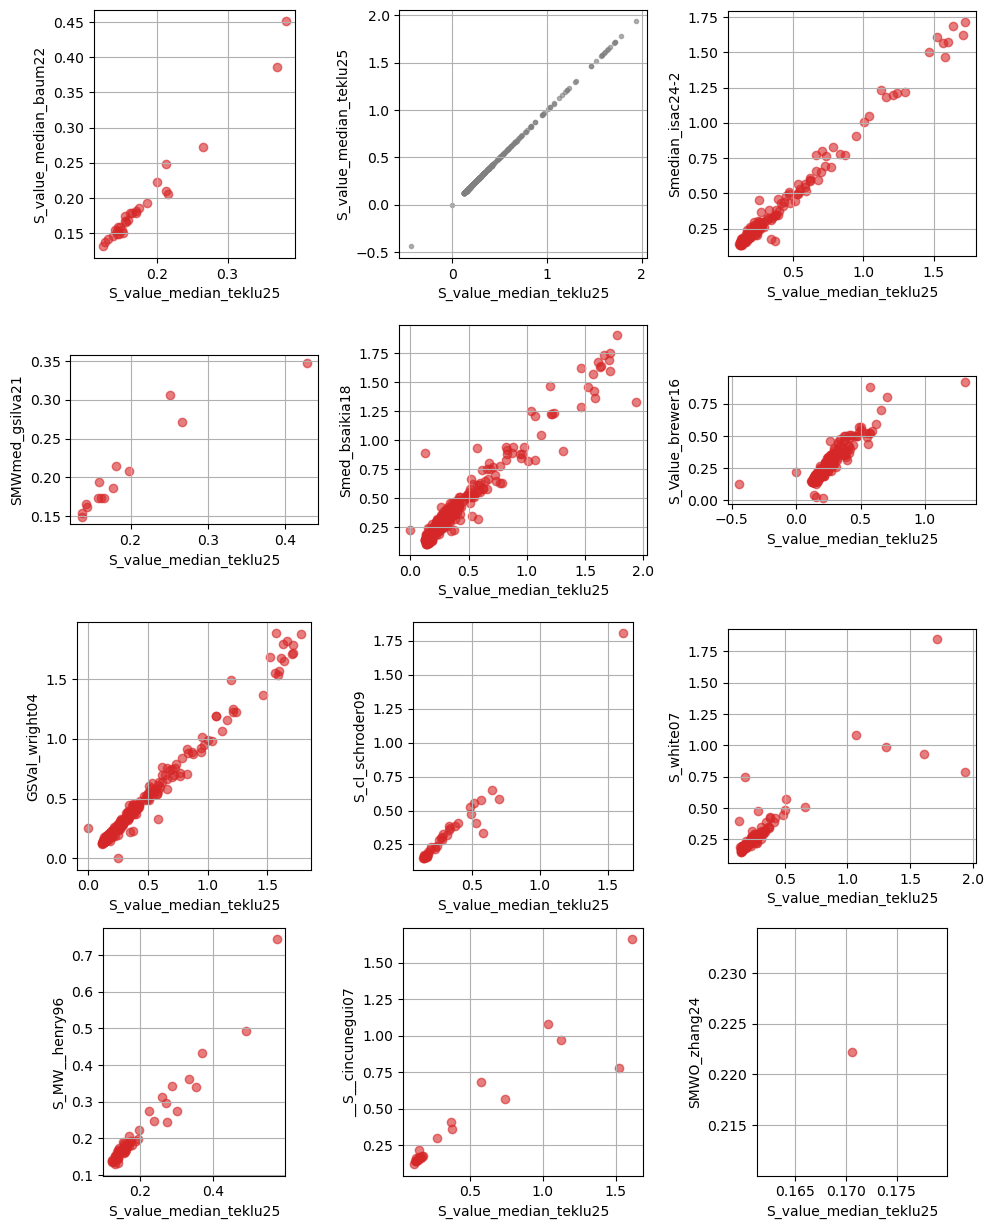

In [5]:
make_panels(merged_HPIC, s_index_columns, 'S_value_median_teklu25')

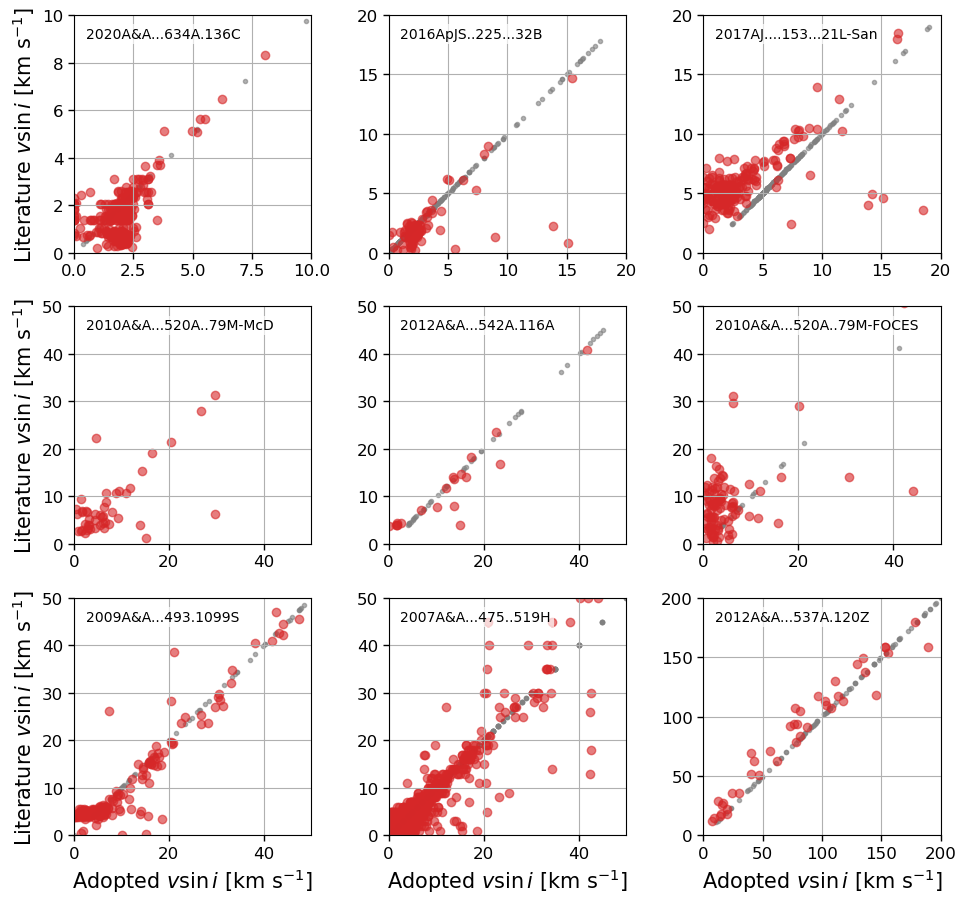

In [6]:
import matplotlib as mpl
mpl.rcParams['font.size'] = 15

to_plot = ['vsini_csilva20', 
           'vsini_brewer16',  
           'vsini_luck17sandiford', 
           'vsini_marnaiz10mcdonald',
           'vsini_avonEiff12',
           'vsini_marnaiz10foces',
           'vsini_schroder09', 
           'vsini_holmberg07',
           'vsini_zorec12']
labels = ['2020A&A...634A.136C', 
          '2016ApJS..225...32B',
          '2017AJ....153...21L-San',
          '2010A&A...520A..79M-McD',
          '2012A&A...542A.116A',
          '2010A&A...520A..79M-FOCES',
          '2009A&A...493.1099S',
          '2007A&A...475..519H',
         '2012A&A...537A.120Z']
fig, axs = make_panels(merged_HPIC,  to_plot, 'vsini_adopt', lim=(0,50))

axs[0].set_xlim(0,10); axs[0].set_ylim(0,10)
for ax in axs[1:3]:
    ax.set_xlim(0,20); ax.set_ylim(0,20)
axs[-1].set_xlim(0,200); axs[-1].set_ylim(0,200)

for i, ax in enumerate(axs):
    ax.tick_params(length=4, width=1, labelsize=12, direction='out')
    ax.set_xlabel(None);     ax.set_ylabel(None)
    ax.text(
    0.05, 0.95,                   
    labels[i],
    transform=ax.transAxes,   
    fontsize=10,
    color="black",
    ha='left', va='top',                
    bbox=dict(
        facecolor='white',
        edgecolor='none',
        alpha=0.7,
        pad=2,
    )
)

    
    
mystr = r'$v\sin i$ [km s$^{-1}$]'
axs[0].set_ylabel('Literature '+mystr)
axs[3].set_ylabel('Literature '+mystr)
axs[6].set_ylabel('Literature '+mystr)

axs[6].set_xlabel('Adopted '+mystr)
axs[7].set_xlabel('Adopted '+mystr)
axs[8].set_xlabel('Adopted '+mystr)

plt.tight_layout()

plt.savefig('plots/verification-vsini.png')


(<Figure size 1000x1240 with 12 Axes>,
 array([<Axes: xlabel='S_index_adopt', ylabel='S_value_median_baum22'>,
        <Axes: xlabel='S_index_adopt', ylabel='S_value_median_teklu25'>,
        <Axes: xlabel='S_index_adopt', ylabel='Smedian_isac24-2'>,
        <Axes: xlabel='S_index_adopt', ylabel='SMWmed_gsilva21'>,
        <Axes: xlabel='S_index_adopt', ylabel='Smed_bsaikia18'>,
        <Axes: xlabel='S_index_adopt', ylabel='S_Value_brewer16'>,
        <Axes: xlabel='S_index_adopt', ylabel='GSVal_wright04'>,
        <Axes: xlabel='S_index_adopt', ylabel='S_cl_schroder09'>,
        <Axes: xlabel='S_index_adopt', ylabel='S_white07'>,
        <Axes: xlabel='S_index_adopt', ylabel='S_MW__henry96'>,
        <Axes: xlabel='S_index_adopt', ylabel='__S__cincunegui07'>,
        <Axes: xlabel='S_index_adopt', ylabel='SMWO_zhang24'>],
       dtype=object))

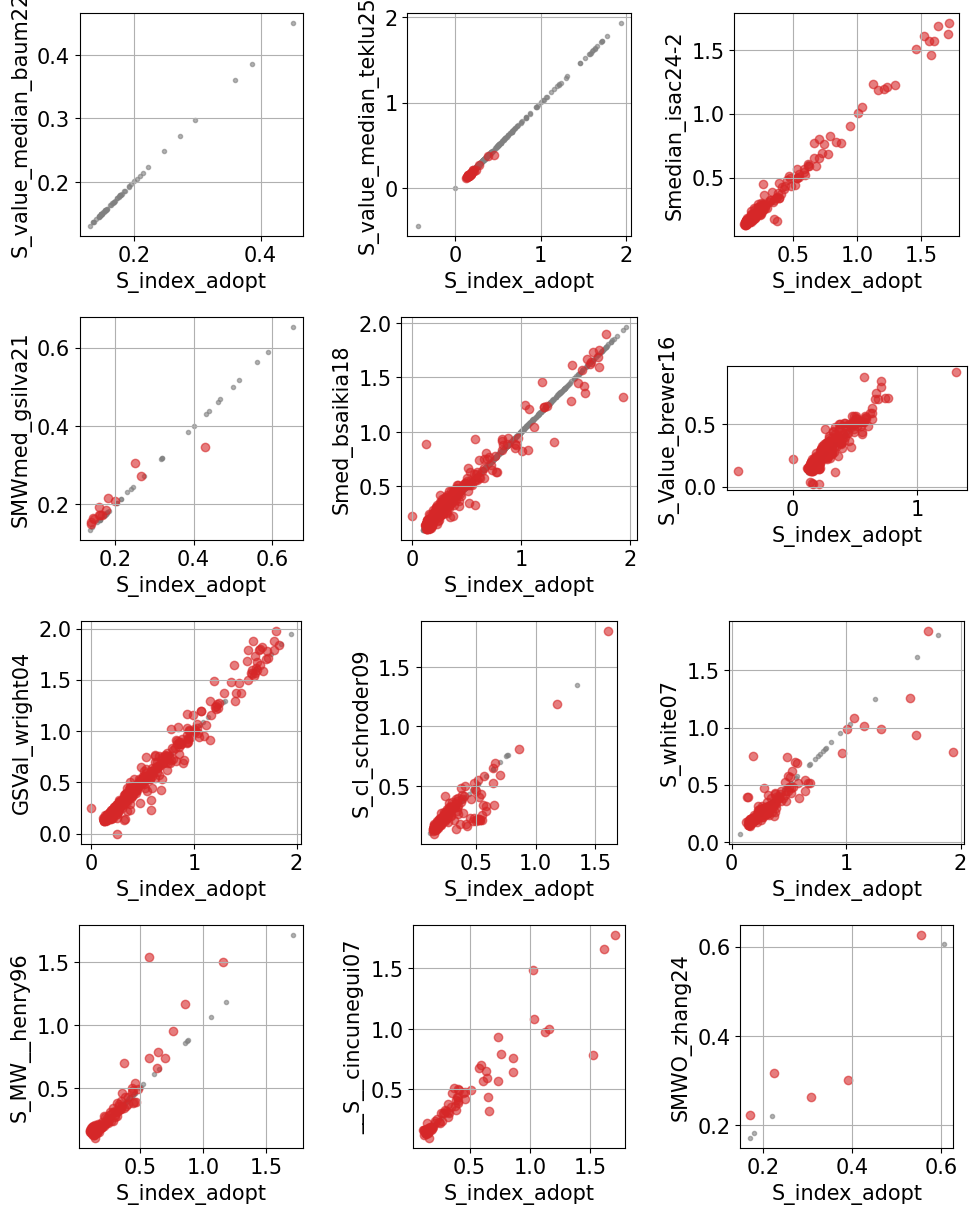

In [7]:
make_panels(merged_HPIC, s_index_columns, 'S_index_adopt')

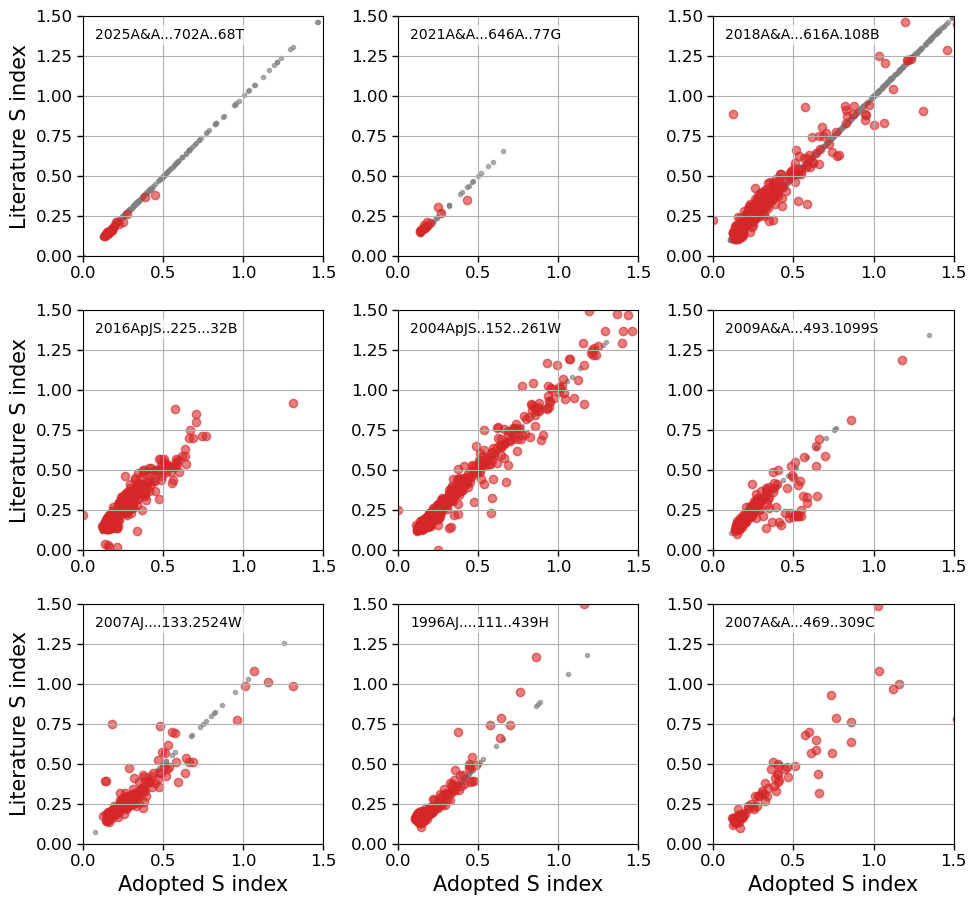

In [8]:
import matplotlib as mpl
mpl.rcParams['font.size'] = 15

to_plot = ["S_value_median_teklu25",
           "SMWmed_gsilva21",
           "Smed_bsaikia18",
           "S_Value_brewer16",
           "GSVal_wright04",
           "S_cl_schroder09",
           "S_white07",
           "S_MW__henry96",
           "__S__cincunegui07"
           #"SMWO_zhang24"
]
labels = ['2025A&A...702A..68T',
          '2021A&A...646A..77G',
          '2018A&A...616A.108B',
          '2016ApJS..225...32B',
          '2004ApJS..152..261W',
          '2009A&A...493.1099S',
          '2007AJ....133.2524W',
          '1996AJ....111..439H',
          '2007A&A...469..309C'
          #'2024A&A...688A..23Z'
         ]
fig, axs = make_panels(merged_HPIC,  to_plot, 'S_index_adopt', lim=(0,50))

for ax in axs:
    ax.set_xlim(0,1.5); ax.set_ylim(0,1.5)

for i, ax in enumerate(axs):
    ax.tick_params(length=4, width=1, labelsize=12, direction='out')
    ax.set_xlabel(None);     ax.set_ylabel(None)
    ax.text(
    0.05, 0.95,                   
    labels[i],
    transform=ax.transAxes,   
    fontsize=10,
    color="black",
    ha='left', va='top',                
    bbox=dict(
        facecolor='white',
        edgecolor='none',
        alpha=0.7,
        pad=2,
    )
)

    
    
axs[0].set_ylabel('Literature S index')
axs[3].set_ylabel('Literature S index')
axs[6].set_ylabel('Literature S index')

axs[6].set_xlabel('Adopted S index')
axs[7].set_xlabel('Adopted S index')
axs[8].set_xlabel('Adopted S index')

plt.tight_layout()
plt.savefig('plots/verification-sval.png')


(<Figure size 1000x1550 with 15 Axes>,
 array([<Axes: xlabel='prot_adopt', ylabel='period_var(d)_christy22'>,
        <Axes: xlabel='prot_adopt', ylabel='period(d)_oelkers18'>,
        <Axes: xlabel='prot_adopt', ylabel='Prot(d)_santos19'>,
        <Axes: xlabel='prot_adopt', ylabel='period(d)_watson06'>,
        <Axes: xlabel='prot_adopt', ylabel='period(days)_briegal22'>,
        <Axes: xlabel='prot_adopt', ylabel='Prot(d)_distefano23'>,
        <Axes: xlabel='prot_adopt', ylabel='period_rot(d)_boyle26'>,
        <Axes: xlabel='prot_adopt', ylabel='period_var(d)_fetherolf23'>,
        <Axes: xlabel='prot_adopt', ylabel='Prot(d)_bsaikia18-2'>,
        <Axes: xlabel='prot_adopt', ylabel='Prot[d]_olah16'>,
        <Axes: xlabel='prot_adopt', ylabel='Prot[d]_smascareno15'>,
        <Axes: xlabel='prot_adopt', ylabel='Prot[d]_mittag17'>,
        <Axes: xlabel='prot_adopt', ylabel='Prot[d]_hempelmann16'>,
        <Axes: >, <Axes: >], dtype=object))

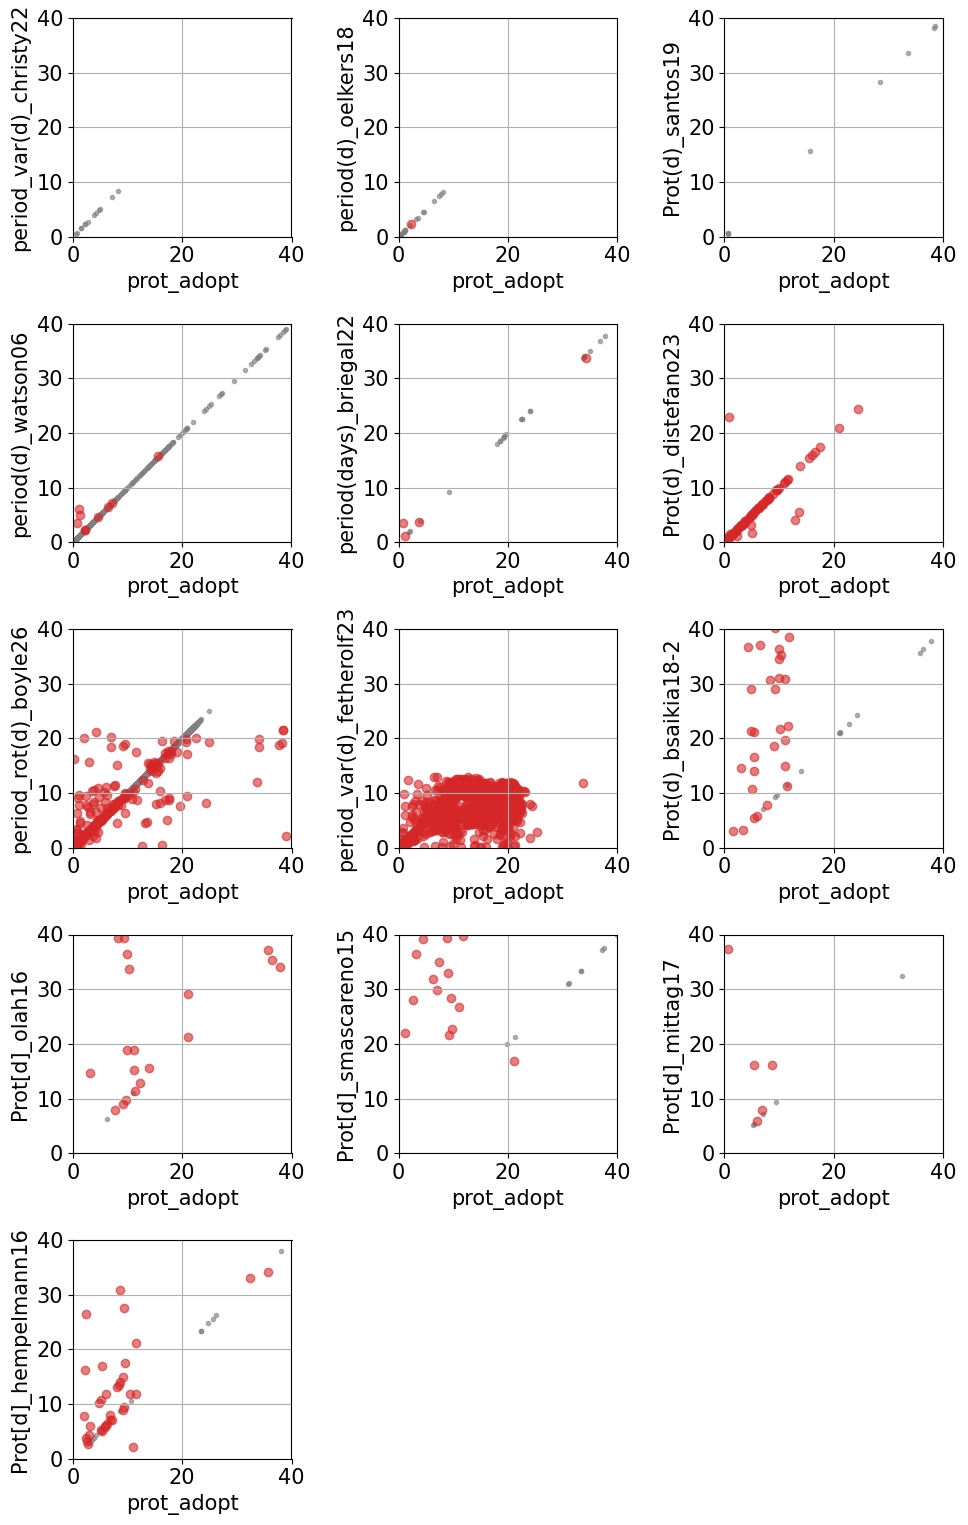

In [9]:
make_panels(merged_HPIC, rotation_period_columns, 'prot_adopt', lim=[0,40])

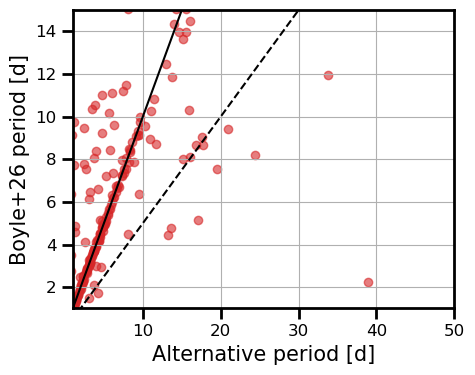

In [ ]:
select_col = 'prot_adopt'
col =  'period_var(d)_fetherolf23' # 'period_rot(d)_boyle26'
subset = merged_HPIC[select_col] == merged_HPIC[col]
fig, ax = plt.subplots(figsize=(5,4))

plt.plot([0,60],[0,60], lw=1.5, c='k')
plt.plot([0,60],[0,30], ls='--', lw=1.5, c='k')
ax.scatter(merged_HPIC[select_col][~subset], merged_HPIC[col][~subset], c='tab:red', alpha=0.6)
ax.set_xlabel('Alternative period [d]')
ax.set_ylabel('Fetherholf+23 period [d]')
ax.grid()
plt.xlim(1,50); plt.ylim(1,15)
#plt.xscale('log'); plt.yscale('log')

ax.tick_params(length=8, width=2, labelsize=12, direction='out')
for xx in ['top','bottom','left','right']:
    ax.spines[xx].set_linewidth(2)
    
plt.tight_layout()
plt.savefig('plots/verification-period-fetherolf23.png')

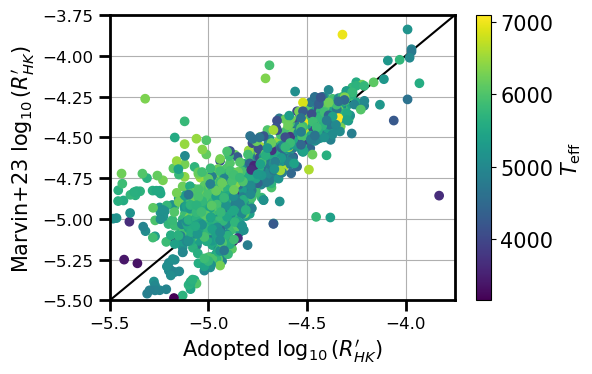

In [11]:
select_col = 'RHK_adopt'
col = 'RHK_calculated_marvin23'
subset = merged_HPIC[select_col] == merged_HPIC[col]

fig, ax = plt.subplots(figsize=(6.1,4))

plt.plot([-5.5,-3.75],[-5.5,-3.75], lw=1.5, c='k')
#plt.plot([0,60],[0,30], ls='--', lw=1.5, c='k')
sc = ax.scatter(merged_HPIC[select_col][~subset], merged_HPIC[col][~subset], c=merged_HPIC['Teff'][~subset], 
           cmap='viridis', zorder=2)
ax.set_xlabel('Adopted period [d]')
ax.set_ylabel('Fetherholf+24 period [d]')
ax.grid()
plt.xlim(-5.5,-3.75); plt.ylim(-5.5,-3.75)
#plt.xscale('log'); plt.yscale('log')

ax.tick_params(length=8, width=2, labelsize=12, direction='out')
for xx in ['top','bottom','left','right']:
    ax.spines[xx].set_linewidth(2)

fig.subplots_adjust(top=0.75)  # Leave enough room at the top

plt.colorbar(sc, label=r'$T_\mathrm{eff}$')
plt.xlabel(r'Adopted $\log_{10}(R^\prime_{HK})$')
plt.ylabel(r'Marvin+23 $\log_{10}(R^\prime_{HK})$')

plt.tight_layout()
plt.savefig('plots/verification-rhk.png')

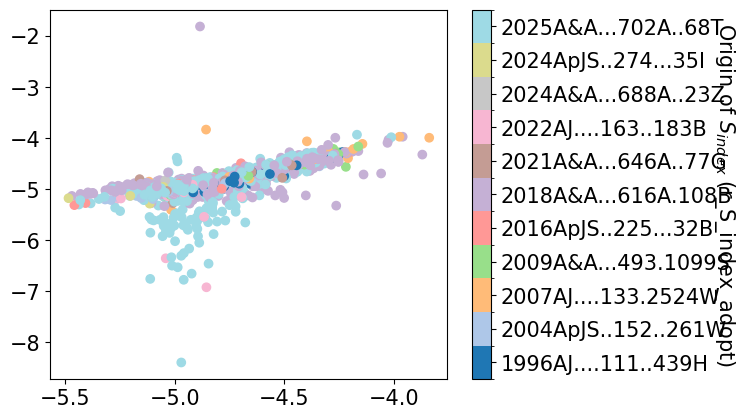

In [12]:
import matplotlib.colors as mcolors
df = (merged_HPIC
      .dropna(subset=['RHK_adopt','r_S_index_adopt'])
      .copy())

# make the origin column categorical → numeric codes for colours
cat = df['r_S_index_adopt'].astype('category')
codes = cat.cat.codes                
labels = cat.cat.categories           

# categorical (qualitative) colormap – e.g. 'tab10' works for ≤10 groups
cmap = plt.get_cmap('tab20')
norm = mcolors.BoundaryNorm(np.arange(-0.5, len(labels)-0.5, 1), cmap.N)

sc = plt.scatter(df['RHK_calculated_marvin23'], df['RHK_adopt'],
            c=codes,
            cmap=cmap,
            norm=norm)

# colour‑bar that acts as a legend for the origins
cbar = plt.colorbar(sc, ticks=np.arange(len(labels)))
cbar.ax.set_yticklabels(labels)      # replace numbers with the actual origin names
cbar.set_label('Origin of $S_{index}$ (r_S_index_adopt)', rotation=270)